Ref `link` for complete details.

The purpose of this collab is to visualize the various edge weight assignments, and then to perform community detection on the PSN. Outputs are not automatically saved, so the user is required to manually save them as required.

In [1]:
!pip install mdanalysis py3Dmol networkx tqdm matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import MDAnalysis as mda
import networkx as nx
import py3Dmol

from networkx.algorithms import community

print("Libraries loaded.")

Libraries loaded.


Upload .pdb and coupling .csv

In [69]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for f in uploaded.keys():
    print(" -", f)


Uploaded files:


Set protein name and coupling method

In [239]:
pname = input("Enter protein name (without extension): ").strip()
method = input("Enter method (contacts/direct/dynamic/bWSME): ").strip()

pdb_file = f"{pname}.pdb"
csv_file = f"{pname}_{method}_coupling.csv"

print(f"\nUsing:")
print("Structure:", pdb_file)
print("Coupling:", csv_file)

Enter protein name (without extension): Villin
Enter method (contacts/direct/dynamic/bWSME): contact

Using:
Structure: Villin.pdb
Coupling: Villin_contact_coupling.csv


Initial visualization


Loading data...
Residues: 35
Matrix shape: (35, 35)


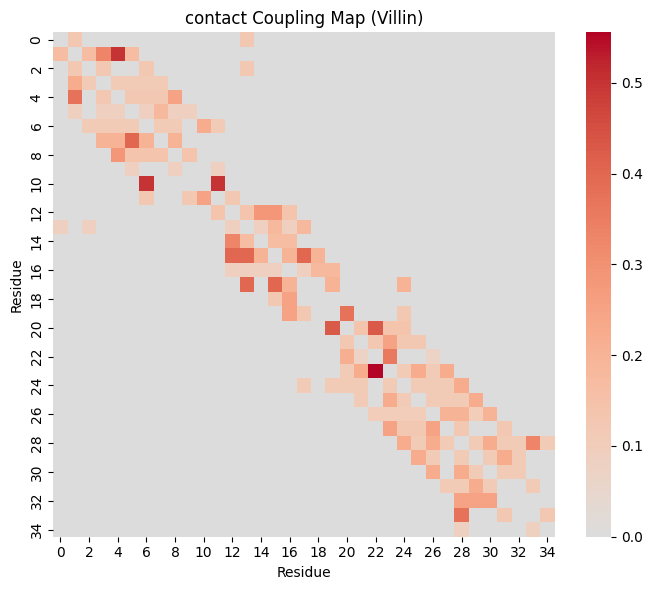

In [240]:
print("\nLoading data...")

u = mda.Universe(pdb_file)
protein = u.select_atoms("protein and name CA")

coords = protein.positions
n_res = len(protein)

coupling = pd.read_csv(csv_file, header=None).values

print(f"Residues: {n_res}")
print(f"Matrix shape: {coupling.shape}")

plt.figure(figsize=(7,6))
sns.heatmap(coupling, cmap="coolwarm", center=0)
plt.title(f"{method} Coupling Map ({pname})")
plt.xlabel("Residue")
plt.ylabel("Residue")
plt.tight_layout()
plt.show()


Loading data...
Residues: 35
Matrix shape: (35, 35)


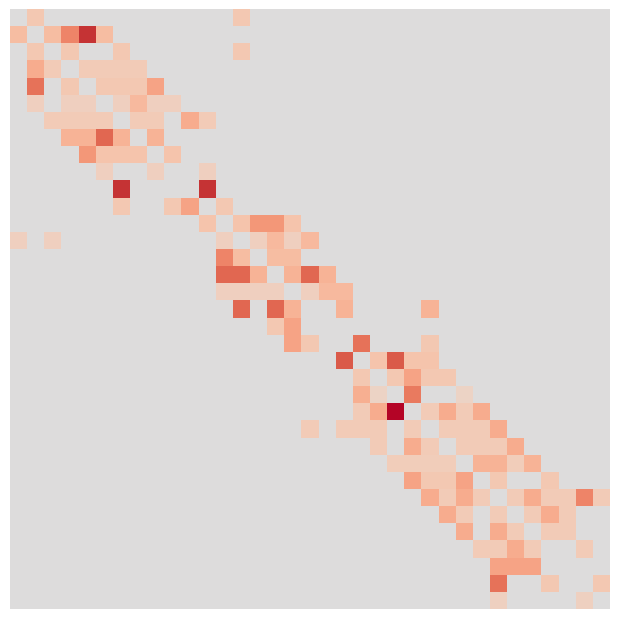

In [241]:
# For paper

print("\nLoading data...")

u = mda.Universe(pdb_file)
protein = u.select_atoms("protein and name CA")


coords = protein.positions
n_res = len(protein)

coupling = pd.read_csv(csv_file, header=None).values

print(f"Residues: {n_res}")
print(f"Matrix shape: {coupling.shape}")

plt.figure(figsize=(6,6))

sns.heatmap(
    coupling,
    cmap="coolwarm",
    center=0,
    cbar=False,
    xticklabels=False,
    yticklabels=False
)

plt.axis('off')
plt.tight_layout(pad=0)

plt.show()

Select threshold of edges and build graph

In [242]:
percent = float(input("Enter top % of edges to keep (e.g. 5 for top 5%): "))

triu_idx = np.triu_indices(n_res, k=1)
values = coupling[triu_idx]
threshold = np.percentile(np.abs(values), 100 - percent)

print(f"Threshold value: {threshold:.4f}")

print("\nBuilding graph...")

G = nx.Graph()

for i in range(n_res):
    G.add_node(i)

edges = []

for i, j in zip(*triu_idx):
    val = coupling[i, j]
    if abs(val) >= threshold:
        G.add_edge(i, j, weight=val)
        edges.append((i, j, val))

print(f"Graph built with {len(edges)} edges.")

Enter top % of edges to keep (e.g. 5 for top 5%): 100
Threshold value: 0.0000

Building graph...
Graph built with 595 edges.


3D Visualization of edges

In [243]:
print("\nRendering 3D structure with coupling edges...")

view = py3Dmol.view(width=800, height=600)
view.addModel(open(pdb_file).read(), "pdb")
view.setStyle({'cartoon': {'color': 'green', 'opacity': 0.5}})

coords = protein.positions
weights = np.array([abs(e[2]) for e in edges])
w_min, w_max = weights.min(), weights.max()

def normalize(w):
    return 0.2 + 0.8 * (w - w_min) / (w_max - w_min + 1e-8)

for i, j, val in edges:
    p1 = coords[i]
    p2 = coords[j]

    color = 'red' if val > 0 else 'blue'
    opacity = normalize(abs(val + 0))
    view.addCylinder({
        'start': {'x': float(p1[0]), 'y': float(p1[1]), 'z': float(p1[2])},
        'end': {'x': float(p2[0]), 'y': float(p2[1]), 'z': float(p2[2])},
        'radius': 0.2,
        'color': color,
        'opacity': float(opacity)
    })

view.zoomTo()
view.show()


Rendering 3D structure with coupling edges...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Community detection

In [249]:
print("\nWeighted Girvan–Newman")

target_k = int(input("Enter desired number of communities: "))

G_gn = G.copy()

for u, v, d in G_gn.edges(data=True):
    d['length'] = 1.0 / (abs(d['weight']) + 1e-8)

def most_valuable_edge(G):
    betweenness = nx.edge_betweenness_centrality(G, weight='length')
    return max(betweenness, key=betweenness.get)

comp_gen = community.girvan_newman(G_gn, most_valuable_edge=most_valuable_edge)
communities_gn = None

for partition in comp_gen:
    current_k = len(partition)

    if current_k >= target_k:
        communities_gn = partition
        break

communities_gn = [list(c) for c in communities_gn]

print(f"\nTarget communities: {target_k}")
print(f"Achieved communities: {len(communities_gn)}")
print(f"Sizes: {[len(c) for c in communities_gn]}")

colors = ['red','blue','yellow','purple','orange','cyan','magenta','lime']

view = py3Dmol.view(width=800, height=600)
view.addModel(open(pdb_file).read(), "pdb")

for i, comm in enumerate(communities_gn):
    color = colors[i % len(colors)]
    for res in comm:
        view.setStyle({'resi': int(res+42)+1}, {'cartoon': {'color': color}})

view.zoomTo()
view.show()


Weighted Girvan–Newman
Enter desired number of communities: 10

Target communities: 10
Achieved communities: 10
Sizes: [26, 1, 1, 1, 1, 1, 1, 1, 1, 1]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [247]:
print("\nWeighted Greedy Modularity...")

communities_greedy = list(
    community.greedy_modularity_communities(G, weight='weight')
)

communities_gr = [list(c) for c in communities_greedy]

print(f"\nCommunities: {len(communities_gr)}")
print(f"Sizes: {[len(c) for c in communities_gr]}")

view = py3Dmol.view(width=800, height=600)
view.addModel(open(pdb_file).read(), "pdb")

for i, comm in enumerate(communities_gr):
    color = colors[i % len(colors)]
    for res in comm:
        view.setStyle({'resi': int(res+42)+1}, {'cartoon': {'color': color}})

view.zoomTo()
view.show()


Weighted Greedy Modularity...

Communities: 4
Sizes: [11, 9, 8, 7]


3Dmol.js failed to load for some reason. Please check your browser console for error messages.